In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
import muon as mu
import builtins #this is because np is shadowing built in sum but can be overwritten using builtins

mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- PDF structure: keep elements separate ---
    'pdf.compression': 0,         # prevents grouping/merging of vector paths
    'savefig.transparent': True,  # optional: preserves transparent backgrounds
    'savefig.bbox': 'tight',      # trims whitespace
    'savefig.pad_inches': 0.02,   # small padding for Illustrator bleed safety

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [2]:
#1. Colours, variable, settings, data

In [3]:
#Plot settings
bar_width = 0.75

In [4]:
#colors
colors_sheet = pd.read_excel('../data/production_color_v1.xlsx') #test sheet

#make leiden cluster color dictionary
colors_dict = dict(zip(colors_sheet.leiden, colors_sheet.colour))

In [5]:
patients = ['P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02', 'P08']
patients2 = ['P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02', 'P08', 'C1', 'C2', 'C3', 'C4', 'C5']
controls = ['C1', 'C2', 'C3', 'C4', 'C5']
ppats = ['P17', 'P18', 'P02', 'P08'] #populate a list of patients who progress

#Manually key in responses 
responses = [['Baseline_Dx', 'Responder', 'Responder'], ['Baseline_Dx', 'Responder', 'Responder'], ['Baseline_Dx', 'Responder', 'Responder'], ['Baseline_Dx', 'Responder', 'Responder'],
            ['Baseline_Dx', 'Non-responder', 'Responder'],
             ['Baseline_Dx', 'Responder', 'Non-responder'], ['Baseline_Dx', 'Responder', 'Non-responder'],            
            ['Baseline_Dx', 'Non-responder', 'Non-responder'],['Baseline_Dx', 'Non-responder', 'Non-responder']]

pt_res = dict(zip(patients, responses))

lclusters = ['2','6','17','21','5','16','12', '1','11','24','4','0','19','3', '10', '7','15','23','18',  '14', '8', '20', '22', '13','9'] #ordered cluster list
lclusters_int = [int(i) for i in lclusters]

ordered_categories_h_leiden_str = ['Atyp','2','6','17','21','5','16','12', '1','11','24']
ordered_categories_h_leiden = ['Atyp',2,6,17,21,5,16,12,1,11,24]

ordered_categories_a_leiden_str = ['4','0','19','3', '10', '7','15','23','18',  '14', '8', '20', '22', '13','9','HSPC-L']
ordered_categories_a_leiden = [4, 0, 19, 3, 10, 7, 15, 23, 18, 14, 8, 20, 22, 13, 9,'HSPC-L']

h_leiden = [2,6,17,21,5,16,12,1,11,24]
h_leiden_str = [str(i) for i in h_leiden]

a_leiden = [4, 0, 19, 3, 10, 7, 15, 23, 18, 14, 8, 20, 22, 13, 9]
a_leiden_str = [str(i) for i in a_leiden]

In [6]:
#Read in data from master h5mu file
adata = mu.read_h5ad('../Data/GEO_data_file_v1.h5mu', mod = 'rna')
print(adata.shape)

(38231, 28762)


In [7]:
#Put celltype proprotions into a df
#Put patient proportions into a dataframe

#First add in harmonised timepoints

df_props = None

time_dict = dict(zip(['C1D1', 'C1D8', 'C6D8', 'C7D1', 'C7D22', 'Progression', 'Healthy', 'C12D29'], ['C1', 'C1', 'C7', 'C7', 'C7', 'End', 'Healthy', 'End'])) #manualcreation of time harmonisation

adata0 = adata.obs.copy()
adata0['time'] = adata0['timepoint'].replace(time_dict)
adata0 = adata0.loc[~adata0['time'].isin(['Healthy'])]

for i, p in enumerate(patients):
    for t in ['C1', 'C7', 'End']: 

        adata1 = adata0.loc[(adata0['time'] == t) & (adata0['patient_alias']==p)]

        # Calculate proportions of each cell type
        df = pd.DataFrame(adata1['leiden'].value_counts(normalize=True) * 100).reset_index()
        df.columns = ['leiden', 'proportion']

        #Get the total proportion of atypical cells and add in to dataframe
        atyp = df.loc[df['leiden'].isin(a_leiden_str)]['proportion'].sum()
        heal = df.loc[df['leiden'].isin(h_leiden_str)]['proportion'].sum()

        df.loc[len(df)] = ['Atyp', atyp] 
        df.loc[len(df)] = ['HSPC-L', heal] 

        #Add extra annotation columns
        df['patient_alias'] = p
        df['timepoint'] = t       

        if df_props is None:
            df_props = df.copy()
        else:
            df_props = pd.concat([df_props, df],ignore_index = True)

#df_props

C:\Users\z3283497\AppData\Local\Temp\ipykernel_25792\2604629640.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata0['time'] = adata0['timepoint'].replace(time_dict)


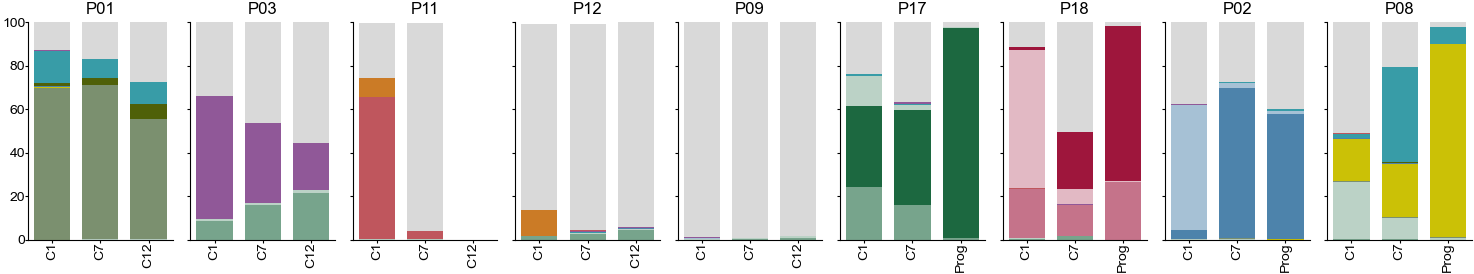

In [15]:
#Plots emphasising atypical vs healthy clusters

fig, ax = plt.subplots(1,9, figsize = (15, 3))

for i, p in enumerate(patients):
    for k, t in enumerate(['C1', 'C7', 'End']):
        df = df_props.loc[(df_props['patient_alias']==p) & (df_props['timepoint']==t)]
        if ((p == 'P11') & (t == 'End')):
            ax[i].bar(k,
             100,
             bar_width,
             bottom = bottom,
             color = '#ffffff') #dummy bar plotted where data is missing
        elif df.empty:
            continue
        else:
            # Sum of all proportions = total bar height
            total_height = df['proportion'].sum()
            #Turn df into a dictionary
            proportion_dict = dict(zip(df.leiden, df.proportion))
            #plot the bar graphs
            bottom = 0
            for category in ordered_categories_a_leiden_str:
                height = proportion_dict.get(category, 0)
                if category == 'HSPC-L':
                    color = colors_dict[category]
                else:
                    color = colors_dict[int(category)]
                ax[i].bar(k,
                         height,
                         bar_width,
                         bottom = bottom,
                         color = color)
                
                bottom += height #update bottom value for next plot

    ax[i].set_ylim(0,100)
    ax[i].set_title(f'{p}', y = 1.0)
    ax[i].set_xticks([0,1,2])
    if p in ppats:
        ax[i].set_xticklabels(['C1', 'C7', 'Prog'], rotation=90)
    else:
        ax[i].set_xticklabels(['C1', 'C7', 'C12'], rotation=90)
    ax[i].tick_params(length=2, pad=0)
    ax[i].spines['top'].set_visible(False) 
    ax[i].spines['right'].set_visible(False) 
    ax[i].set_xlim(-0.5, 2.5)


for g in range(8):
    ax[g+1].set_yticklabels('')
            

fig.tight_layout()

#fig.savefig('../Figures/3_Atypical_proportions_leiden_v1_GEO.pdf',bbox_inches='tight', format='pdf', dpi = 600)

C:\Users\z3283497\AppData\Local\Temp\ipykernel_25792\4190353035.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = [row[1], row[2], row[3]]
C:\Users\z3283497\AppData\Local\Temp\ipykernel_25792\4190353035.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = colors_dict[int(row[0])]
C:\Users\z3283497\AppData\Local\Temp\ipykernel_25792\4190353035.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = [row[1], row[2], ro

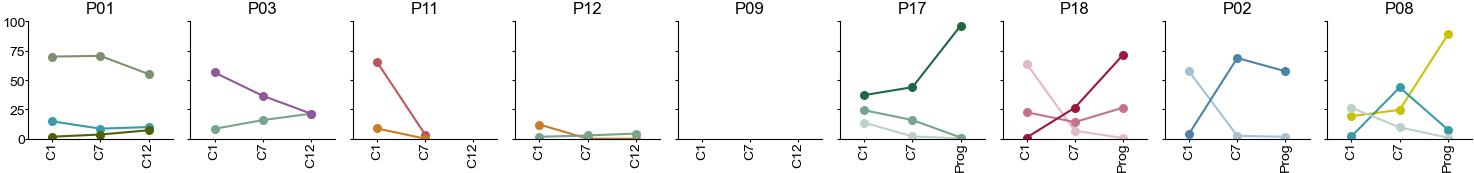

In [17]:
#Line plots of cluster dynamics
fig, ax = plt.subplots(1,9, figsize = (15, 2))

for i, p in enumerate(patients):
    df = df_props.loc[(df_props['patient_alias']==p)]
    reshaped = df.pivot(index = 'leiden', columns = 'timepoint', values = 'proportion').reset_index()
    reshaped = reshaped.loc[(reshaped['leiden'].isin(a_leiden_str)) & (reshaped[['C1', 'C7', 'End']].sum(axis=1) >5)] #only keep clusters that are at least 5% of cells
    
    for j, row in reshaped.iterrows():
        if p == 'P11':
            y = [row[1], row[2]]
            x = [0,1]
            color = colors_dict[int(row[0])]
            ax[i].plot(x,y,color) 
            ax[i].scatter(x,y,marker = 'o', color=color, linewidth=1, zorder = 2, s = 30)
        else:
            y = [row[1], row[2], row[3]]
            x = [0,1,2]
            color = colors_dict[int(row[0])]
            #print(p, x, y, color)
            ax[i].plot(x,y,color) 
            ax[i].scatter(x,y,marker = 'o', color=color, linewidth=1, zorder = 2, s = 30)

    ax[i].set_ylim(0,100)
    ax[i].set_title(f'{p}', y = 1.0)
    ax[i].set_xticks([0,1,2])
    if p in ppats:
        ax[i].set_xticklabels(['C1', 'C7', 'Prog'], rotation=90)
    else:
        ax[i].set_xticklabels(['C1', 'C7', 'C12'], rotation=90)
    ax[i].tick_params(length=2, pad=0)
    ax[i].spines['top'].set_visible(False) 
    ax[i].spines['right'].set_visible(False) 
    ax[i].set_xlim(-0.5, 2.5)

for g in range(8):
    ax[g+1].set_yticklabels('')
            

fig.tight_layout()

#fig.savefig('../Figures/3_Atypical_proportions_lines_leiden_v1_GEO.pdf',bbox_inches='tight', format='pdf', dpi = 600)